ライブラリーのインポート

In [1]:
import numpy as np
import rasterio as rio
import matplotlib.pyplot as plt
import japanize_matplotlib

画像パスの設定

In [2]:
INPUT_IMG = '/workspace/data/IMG-VV-STRIX1-20221212T192710Z-SMGRD.tif'
OUTPUT_IMG = '/workspace/output/IMG-VV-STRIX1-20221212T192710Z-SMGRD_clip.tif'

元画像の読み込みと可視化

In [4]:
# メタ情報で設定されている校正係数
CALIBRATION_FACTOR = 251.2

# 画像の読み込み
with rio.open(INPUT_IMG) as src:
    img = src.read(1).astype(np.float32)
    sigma = (img ** 2) / (CALIBRATION_FACTOR ** 2)
    sigma[sigma == 0] = np.nan
    sigma_sqrt = np.sqrt(sigma)

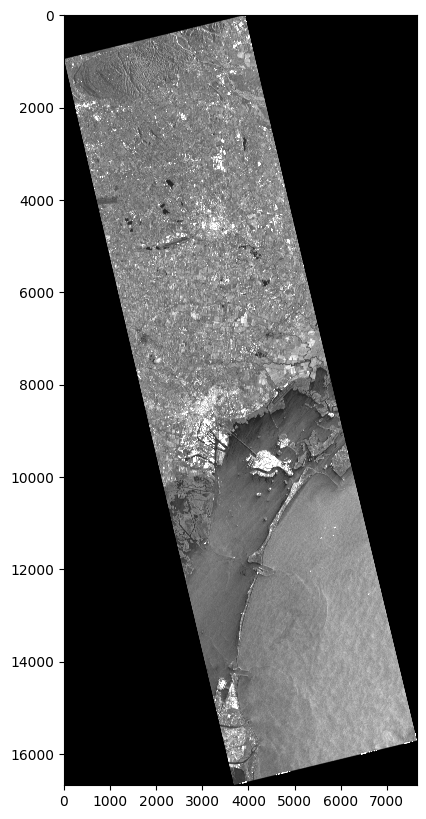

In [45]:
# 画像の可視化
p2, p98 = np.percentile(simga_sqrt, [2, 98])

plt.figure(figsize=(10, 10))
plt.imshow(sigma_sqrt, cmap="gray", vmin=p2, vmax=p98)
plt.show()

画像の読み込み、切り取り、保存

In [67]:
# 画像の読み込み、切り取り
with rio.open(INPUT_IMG) as src:
    out_meta = src.meta.copy()
    
    img = src.read(1).astype(np.float32)
    sigma = (img ** 2) / (CALIBRATION_FACTOR ** 2)
    sigma[sigma == 0] = np.nan
    
    # window = rio.windows.Window(col_off=3850, row_off=4970, width=330, height=300)
    window = rio.windows.Window(col_off=2040, row_off=4100, width=230, height=220)
    transform = rio.windows.transform(window, src.transform)
    out_meta.update({
        "driver": "GTiff",
        "height": window.height,
        "width": window.width,
        "transform": transform,
        "dtype": 'float32'
    })

    img_clip = sigma[window.row_off:window.row_off+window.height, window.col_off:window.col_off+window.width]

# 結果を保存
with rio.open(OUTPUT_IMG, "w", **out_meta) as dest:
    dest.write(img_clip, 1)

切り取った画像の可視化

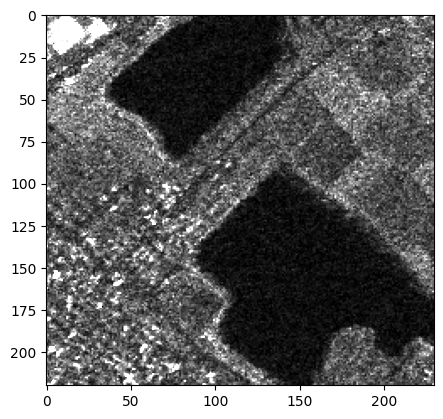

In [69]:
with rio.open(OUTPUT_IMG) as src:
    sigma_clip = src.read(1).astype(np.float32)
    sigma_clip_sqrt = np.sqrt(sigma_clip)
    
p2, p98 = np.percentile(sigma_clip_sqrt, [2, 98])

plt.figure(figsize=(5, 5))
plt.imshow(sigma_clip_sqrt, cmap="gray", vmin=p2, vmax=p98)
plt.show()

切り取った画像の読み込みとヒストグラムの表示

In [ ]:
with rio.open(OUTPUT_IMG) as src:
    img = src.read(1).astype(np.float32)
    img_dB = 10 * np.log10(img)

p2, p98 = np.percentile(img_dB, [2, 98])

plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(img_dB, cmap='gray', vmin=p2, vmax=p98)
plt.title('解析画像', fontsize=15)
plt.subplot(1, 2, 2)
plt.hist(img_dB.flatten(), bins=100)
plt.title('解析画像のヒストグラム', fontsize=15)
plt.tight_layout()
plt.show()    

Valley Emphasisの関数設定

In [ ]:
def valley_emphasis(image):
    min_val = np.nanmin(image)
    max_val = np.nanmax(image)

    bins = int((max_val - min_val) * 10) + 1
    counts, bin_edges = np.histogram(image, bins=bins, range=(min_val, max_val))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    total = image.size
    
    sum_val = np.sum(bin_centers * counts / total)
    
    var_max = 0
    threshold = 0
    
    omega_1 = 0
    omega_2 = 0
    mu_k = 0
    
    for t in range(bins):
        omega_1 += counts[t] / total
        omega_2 = 1 - omega_1
        mu_k += bin_centers[t] * counts[t] / total
        
        if omega_1 == 0:
            mu_1 = 0
        else:
            mu_1 = mu_k / omega_1
        
        if omega_2 == 0:
            mu_2 = 0
        else:
            mu_2 = (sum_val - mu_k) / omega_2
        
        current_var = (1 - counts[t] / total) * (omega_1 * (mu_1 ** 2) + omega_2 * (mu_2 ** 2))
        
        if current_var > var_max:
            var_max = current_var
            threshold = bin_centers[t]
    
    return threshold

Valley Emphasis手法を用いた2値化の実行

In [ ]:
threshold = valley_emphasis(img_dB)
print(threshold)

2値化の結果の可視化

In [ ]:
plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(np.where(img_dB < threshold, 1, 0), cmap='gray')
plt.title('水域マスク', fontsize=15)
plt.show()    

In [ ]:
# 画像の保存
plt.figure(figsize=(20, 10))
plt.imshow(np.where(img_dB < threshold, 1, 0), cmap='gray')
plt.axis('off')

plt.savefig('/workspace/output/water_delineation.png')
plt.show()    